In [1]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Dataset Info:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= =====...
Training set: 105 samples
Test set: 45 samples
Number of features: 4
Number of classes: 3


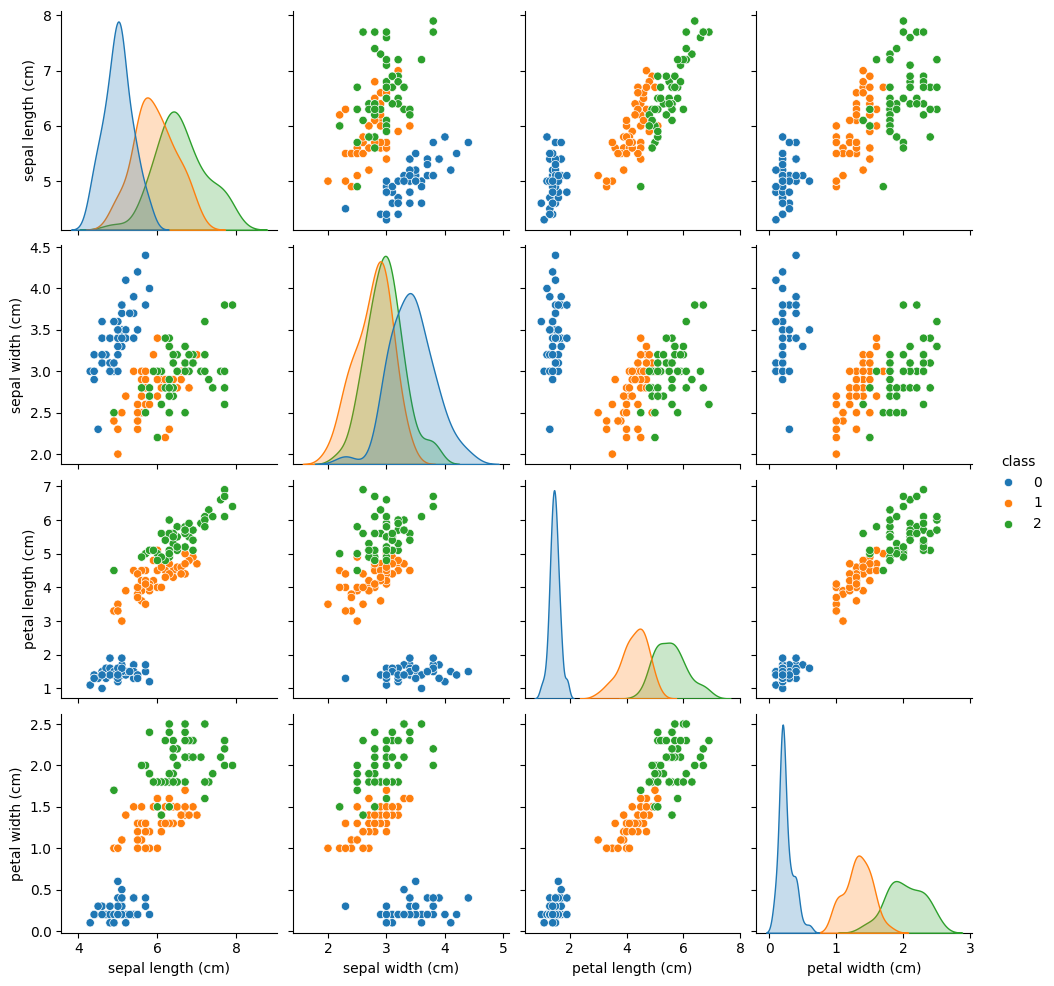

In [2]:
# Load and preprocess data
iris_data = load_iris()
print("Dataset Info:")
print(iris_data.DESCR[:500] + "...")

features = iris_data.data
labels = iris_data.target

# Normalize features to [0, 1] range for quantum encoding
features = MinMaxScaler().fit_transform(features)

# Split data
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, test_size=0.3, random_state=42, stratify=labels
)

print(f"Training set: {train_features.shape[0]} samples")
print(f"Test set: {test_features.shape[0]} samples")
print(f"Number of features: {features.shape[1]}")
print(f"Number of classes: {len(np.unique(labels))}")

# Visualize data
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df["class"] = pd.Series(iris_data.target)
sns.pairplot(df, hue="class", palette="tab10")
plt.show()

In [3]:
# Circuit parameters
num_qubits = 4  # One qubit per feature
num_layers = 3  # Equivalent to reps=3 in Qiskit

# Create quantum device
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev, diff_method="backprop")
def quantum_circuit(features, weights):
    """
    Variational Quantum Classifier Circuit

    Equivalent to Qiskit's ZZFeatureMap + RealAmplitudes:
    - Feature Map: AngleEmbedding (similar to ZZFeatureMap encoding)
    - Ansatz: StronglyEntanglingLayers (more powerful than RealAmplitudes)
    """

    # FEATURE MAP: Encode classical data into quantum states
    # This is equivalent to ZZFeatureMap in Qiskit
    qml.AngleEmbedding(features, wires=range(num_qubits))

    # ANSATZ: Trainable variational circuit  
    # StronglyEntanglingLayers is more expressive than RealAmplitudes
    qml.StronglyEntanglingLayers(weights, wires=range(num_qubits))

    # MEASUREMENT: Multi-class classification
    # Return expectation values for classification
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]  # 3 classes


Circuit Structure:
Qubits: 4
Layers: 3
Weight shape: (3, 4, 3)
Total parameters: 36

Quantum Circuit:
(<Figure size 1900x500 with 1 Axes>, <Axes: >)


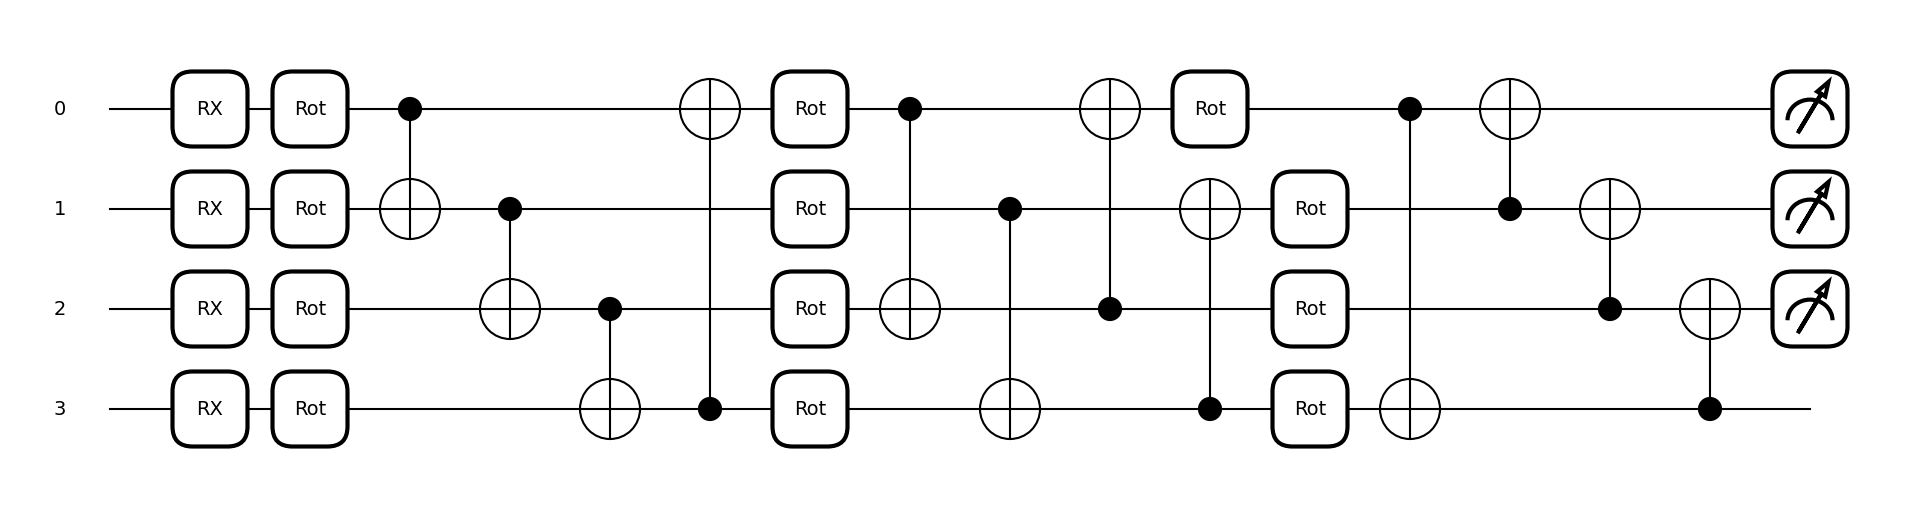

In [4]:
# Initialize weights for the ansatz
weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=num_layers, n_wires=num_qubits)
weights = np.random.normal(0, 0.1, size=weight_shape, requires_grad=True)

print(f"\nCircuit Structure:")
print(f"Qubits: {num_qubits}")
print(f"Layers: {num_layers}")
print(f"Weight shape: {weight_shape}")
print(f"Total parameters: {np.prod(weight_shape)}")

# Visualize the circuit
print("\nQuantum Circuit:")
sample_features = train_features[0]
drawer = qml.draw_mpl(quantum_circuit, expansion_strategy="device")
print(drawer(sample_features, weights))

In [5]:
def predict_class(features, weights):
    """Predict class from quantum circuit outputs"""
    outputs = quantum_circuit(features, weights)
    return np.argmax(outputs)

def accuracy(predictions, targets):
    """Calculate accuracy"""
    return np.mean(predictions == targets)

def cost_function(weights, features_batch, labels_batch):
    """
    Multi-class classification cost function
    Uses squared loss for each class
    """
    total_cost = 0
    for i in range(len(features_batch)):
        # Get quantum circuit outputs
        outputs = quantum_circuit(features_batch[i], weights)

        # Create one-hot encoded target
        target = np.zeros(3)
        target[labels_batch[i]] = 1

        # Convert outputs to probabilities (softmax-like)
        probs = np.exp(outputs) / np.sum(np.exp(outputs))

        # Cross-entropy loss
        cost = -np.sum(target * np.log(probs + 1e-8))
        total_cost += cost

    return total_cost / len(features_batch)

# Alternative simpler cost function (closer to Qiskit VQC)
def simple_cost_function(weights, features_batch, labels_batch):
    """Simplified cost function using direct expectation values"""
    predictions = []
    targets = []

    for i in range(len(features_batch)):
        outputs = quantum_circuit(features_batch[i], weights)
        pred_class = np.argmax(outputs)
        predictions.append(pred_class)
        targets.append(labels_batch[i])

    # Return negative accuracy (to minimize)
    return 1 - accuracy(np.array(predictions), np.array(targets))

In [6]:
# Training parameters
optimizer = AdamOptimizer(stepsize=0.1)
batch_size = 10
num_epochs = 50

# Training history
cost_history = []
train_accuracy_history = []
test_accuracy_history = []

print("\n=== Training VQC ===")
print("Starting training...")

import time
start_time = time.time()

for epoch in range(num_epochs):
    # Shuffle training data
    indices = np.random.permutation(len(train_features))
    train_features_shuffled = train_features[indices]
    train_labels_shuffled = train_labels[indices]

    # Batch training
    epoch_cost = 0
    num_batches = len(train_features) // batch_size

    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size

        batch_features = train_features_shuffled[start_idx:end_idx]
        batch_labels = train_labels_shuffled[start_idx:end_idx]

        # Update weights
        def cost_fn(w):
            return simple_cost_function(w, batch_features, batch_labels)

        weights, cost = optimizer.step_and_cost(cost_fn, weights)
        epoch_cost += cost

    avg_cost = epoch_cost / num_batches
    cost_history.append(avg_cost)

    # Calculate accuracies every 5 epochs
    if epoch % 5 == 0:
        # Training accuracy
        train_predictions = []
        for i in range(len(train_features)):
            pred = predict_class(train_features[i], weights)
            train_predictions.append(pred)
        train_acc = accuracy(np.array(train_predictions), train_labels)
        train_accuracy_history.append(train_acc)

        # Test accuracy  
        test_predictions = []
        for i in range(len(test_features)):
            pred = predict_class(test_features[i], weights)
            test_predictions.append(pred)
        test_acc = accuracy(np.array(test_predictions), test_labels)
        test_accuracy_history.append(test_acc)

        print(f"Epoch {epoch:2d}: Cost = {avg_cost:.4f}, "
              f"Train Acc = {train_acc:.3f}, Test Acc = {test_acc:.3f}")

elapsed_time = time.time() - start_time
print(f"\nTraining completed in {elapsed_time:.1f} seconds")


=== Training VQC ===
Starting training...
Epoch  0: Cost = 0.3400, Train Acc = 0.657, Test Acc = 0.667
Epoch  5: Cost = 0.3400, Train Acc = 0.657, Test Acc = 0.667
Epoch 10: Cost = 0.3400, Train Acc = 0.657, Test Acc = 0.667
Epoch 15: Cost = 0.3300, Train Acc = 0.657, Test Acc = 0.667
Epoch 20: Cost = 0.3400, Train Acc = 0.657, Test Acc = 0.667
Epoch 25: Cost = 0.3500, Train Acc = 0.657, Test Acc = 0.667
Epoch 30: Cost = 0.3400, Train Acc = 0.657, Test Acc = 0.667
Epoch 35: Cost = 0.3500, Train Acc = 0.657, Test Acc = 0.667
Epoch 40: Cost = 0.3200, Train Acc = 0.657, Test Acc = 0.667
Epoch 45: Cost = 0.3500, Train Acc = 0.657, Test Acc = 0.667

Training completed in 149.1 seconds


In [7]:
# Final predictions
final_train_predictions = []
for i in range(len(train_features)):
    pred = predict_class(train_features[i], weights)
    final_train_predictions.append(pred)

final_test_predictions = []
for i in range(len(test_features)):
    pred = predict_class(test_features[i], weights)
    final_test_predictions.append(pred)

final_train_acc = accuracy(np.array(final_train_predictions), train_labels)
final_test_acc = accuracy(np.array(final_test_predictions), test_labels)

print("\n=== Final Results ===")
print(f"PennyLane VQC on training dataset: {final_train_acc:.3f}")
print(f"PennyLane VQC on test dataset:     {final_test_acc:.3f}")


=== Final Results ===
PennyLane VQC on training dataset: 0.657
PennyLane VQC on test dataset:     0.667


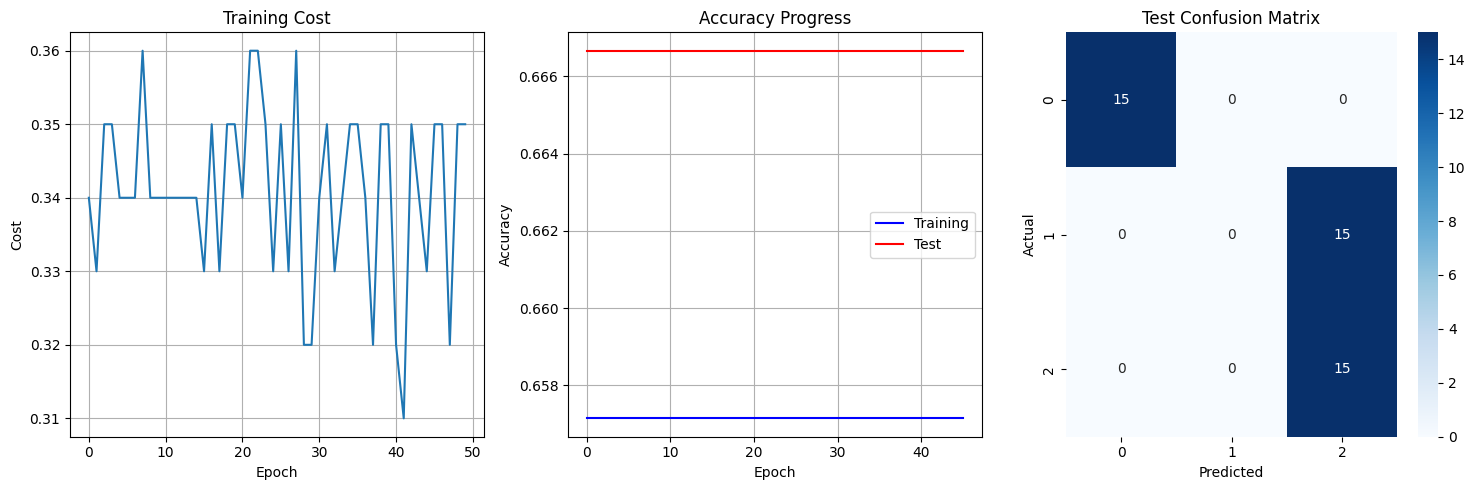

In [8]:
# Plot training progress
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(cost_history)
plt.title('Training Cost')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True)

plt.subplot(1, 3, 2)
epochs_acc = list(range(0, num_epochs, 5))
plt.plot(epochs_acc, train_accuracy_history, 'b-', label='Training')
plt.plot(epochs_acc, test_accuracy_history, 'r-', label='Test')
plt.title('Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
# Confusion matrix-like visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, final_test_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()
